In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [14]:
df = pd.read_csv("D:\\DATA_PROJECT\\data\\cleaned_heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.952197,0.681005,1.973123,0.763956,-0.256334,2.394438,-1.005832,0.015443,-0.696631,1.087338,-2.274579,-0.714429,-2.148873,0.914529
1,-1.915313,0.681005,1.002577,-0.092738,0.072199,-0.417635,0.898962,1.633471,-0.696631,2.122573,-2.274579,-0.714429,-0.512922,0.914529
2,-1.474158,-1.468418,0.032031,-0.092738,-0.816773,-0.417635,-1.005832,0.977514,-0.696631,0.310912,0.976352,-0.714429,-0.512922,0.914529
3,0.180175,0.681005,0.032031,-0.663867,-0.198357,-0.417635,0.898962,1.239897,-0.696631,-0.206705,0.976352,-0.714429,-0.512922,0.914529
4,0.290464,-1.468418,-0.938515,-0.663867,2.082050,-0.417635,0.898962,0.583939,1.435481,-0.379244,0.976352,-0.714429,-0.512922,0.914529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.290464,-1.468418,-0.938515,0.478391,-0.101730,-0.417635,0.898962,-1.165281,1.435481,-0.724323,-0.649113,-0.714429,1.123029,-1.093459
299,-1.033002,0.681005,1.973123,-1.234996,0.342756,-0.417635,0.898962,-0.771706,-0.696631,0.138373,-0.649113,-0.714429,1.123029,-1.093459
300,1.503641,0.681005,-0.938515,0.706843,-1.029353,2.394438,0.898962,-0.378132,-0.696631,2.036303,-0.649113,1.244593,1.123029,-1.093459
301,0.290464,0.681005,-0.938515,-0.092738,-2.227533,-0.417635,0.898962,-1.515125,1.435481,0.138373,-0.649113,0.265082,1.123029,-1.093459


In [15]:
df.shape

(303, 14)

✅ Optimal number of components to retain 95% variance: 13
🎉 PCA-transformed dataset saved to data/pca_heart.csv
📊 PCA variance plot saved to results/pca_variance_plot.png


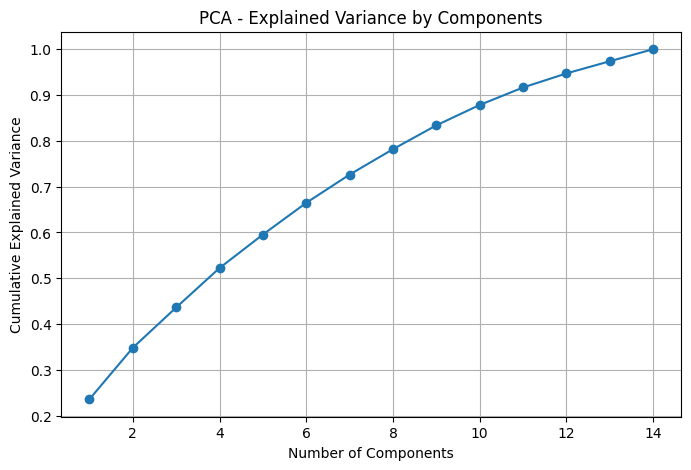

In [18]:
# 2. Apply PCA
pca = PCA()
pca_data = pca.fit_transform(df)

# 3. Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# 4. Choose number of components (keep 95% variance)
cum_var = explained_variance.cumsum()
n_components = (cum_var < 0.95).sum() + 1
print(f"✅ Optimal number of components to retain 95% variance: {n_components}")

# 5. Transform dataset with optimal components
pca_final = PCA(n_components=n_components)
pca_transformed = pca_final.fit_transform(df)

# 6. Save PCA dataset
pca_df = pd.DataFrame(pca_transformed, columns=[f"PC{i+1}" for i in range(n_components)])
pca_df.to_csv("D:\\DATA_PROJECT\\data\\pca_heart.csv", index=False)
print("🎉 PCA-transformed dataset saved to data/pca_heart.csv")

# 7. Visualizations
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance by Components")
plt.grid(True)
plt.savefig("D:\\DATA_PROJECT\\data\\pca_variance_plot.png")
print("📊 PCA variance plot saved to results/pca_variance_plot.png")